# OpenCV
Этот ноутбук призван продемонстрировать вам некоторые возможности библиотеки OpenCV. Перед использованием закиньте изображение Лены в Colab.

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Для начала прочитаем наше изображение.

In [9]:
img = cv2.imread('peshehod.jpeg')

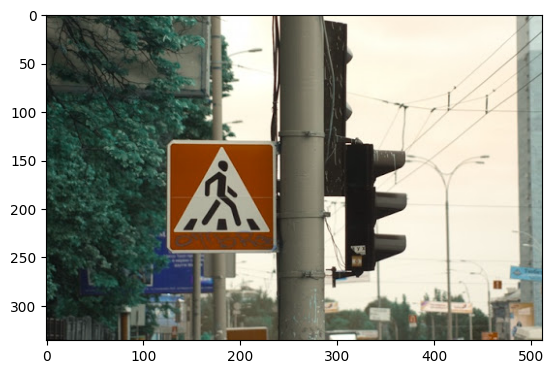

In [ ]:
pesh = cv2.imread('peshehod.jpeg')
plt.imshow(pesh) 

Запринтим изображение, чтобы увидеть, как оно выглядит с точки зрения компьютера:

In [18]:
print(img)

[[[ 67  73  71]
  [ 64  73  70]
  [ 55  65  57]
  ...
  [215 223 208]
  [215 223 208]
  [212 220 205]]

 [[ 47  56  53]
  [ 53  62  59]
  [ 61  70  65]
  ...
  [215 223 208]
  [216 224 209]
  [212 220 205]]

 [[ 23  32  29]
  [ 25  34  31]
  [ 39  48  43]
  ...
  [216 224 209]
  [216 224 209]
  [211 219 204]]

 ...

 [[ 26  28  27]
  [ 22  24  23]
  [ 21  23  22]
  ...
  [179 199 206]
  [179 199 206]
  [180 200 207]]

 [[ 31  33  32]
  [ 27  29  28]
  [ 24  26  25]
  ...
  [153 176 184]
  [154 177 185]
  [154 177 185]]

 [[ 10  12  11]
  [ 11  13  12]
  [ 13  15  14]
  ...
  [118 143 150]
  [119 144 151]
  [120 145 152]]]


А теперь, с помощью matplotlib (так удобнее) отрисуем изображение уже в виде изображения:

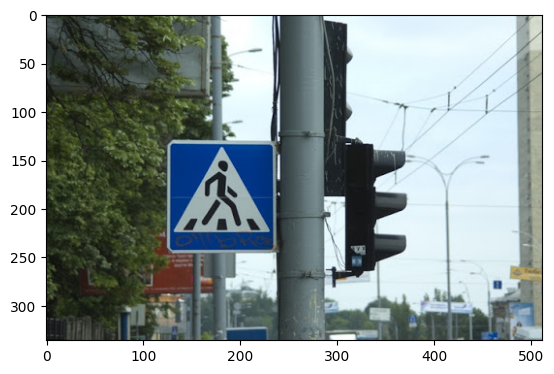

In [19]:
plt.imshow(img)
plt.show()

Видим, что изображение какое-то синее. Дело в том, что часто при чтении изображения оно читается как BGR, а не RGB, но это не трудно исправить

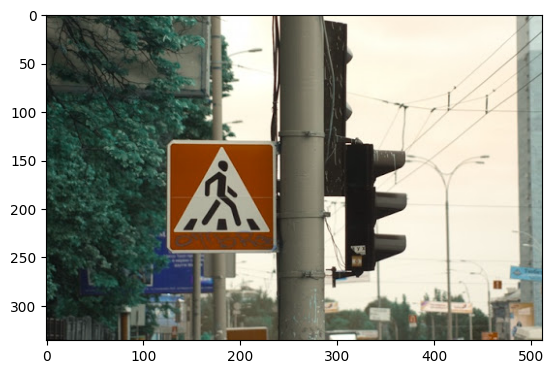

In [20]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

# Кадрирование
Вот теперь все в порядке, можем начать издеваться над нашей Леной. Начнем с кадрирования изображения. Это очень легко делать, просто используя стандартные срезы матрицы нумпая.

ValueError: zero-size array to reduction operation minimum which has no identity

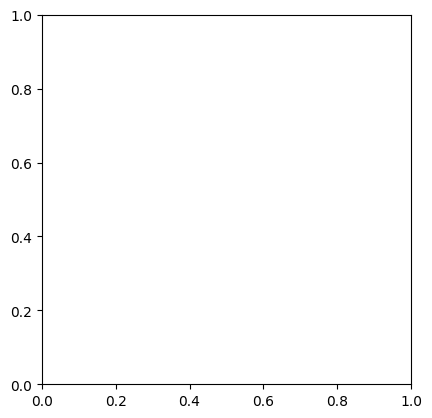

In [26]:
cropped_img = img[500:190, 500:150]
plt.imshow(cropped_img)
plt.show()

## Изменение размера

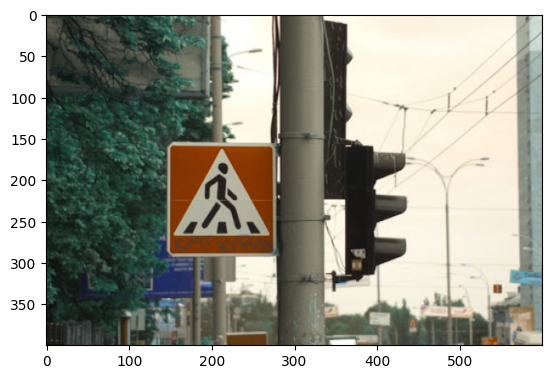

In [27]:
resized_img = cv2.resize(img, (600, 400), interpolation = cv2.INTER_AREA)
plt.imshow(resized_img)
plt.show()

# Рисование прямоугольников

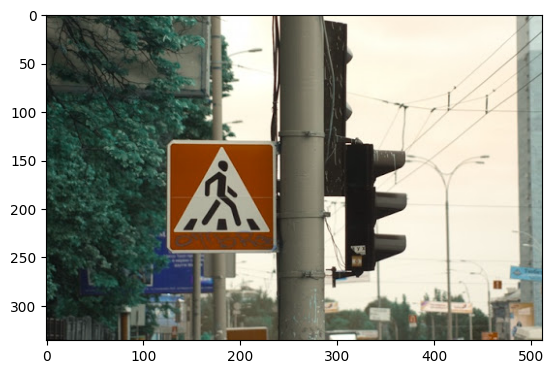

In [28]:
output = img.copy()
cv2.rectangle(output, (550, 200), (1500, 1600), (0, 255, 255), 10)
plt.imshow(output)
plt.show()

# Текст на изображении

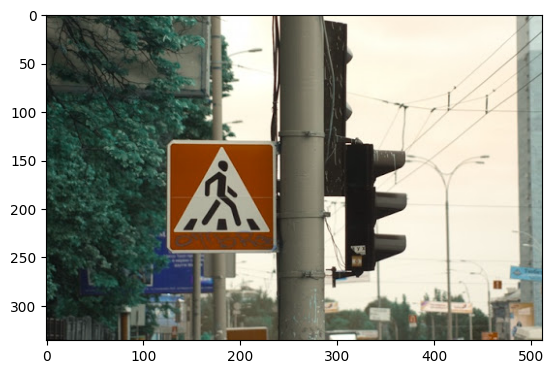

In [29]:
output = img.copy()
cv2.putText(output, "Lenna", (500, 1800), cv2.FONT_HERSHEY_SIMPLEX, 15, (30, 105, 210), 40) 
plt.imshow(output)
plt.show()

# Градации серого и threshold

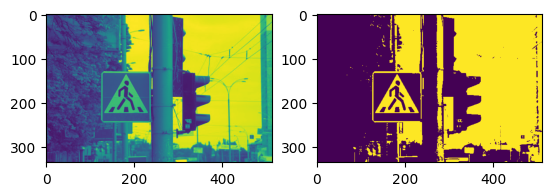

In [30]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, thresholded_img = cv2.threshold(gray_img, 127, 255, 0)
plt.subplot(121)
plt.imshow(gray_img)
plt.subplot(122)
plt.imshow(thresholded_img)
plt.show()

Мы столкнулись с проблемой отображения одномерных изображений, надо отдельно указывать цветовую карту. Сделаем это.

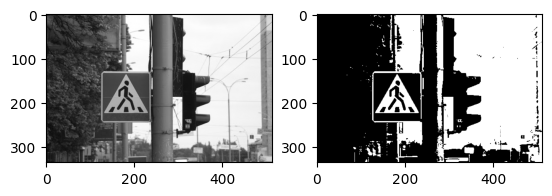

In [31]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, thresholded_img = cv2.threshold(gray_img, 127, 255, 0)
plt.subplot(121)
plt.imshow(gray_img, cmap='gray')
plt.subplot(122)
plt.imshow(thresholded_img, cmap='gray')
plt.show()

# Фильтры
Теперь можно пройтись по различным фильтрами, они пригодятся вам, когда у вас будут зашумленные изображения

In [33]:
noise = np.random.randint(
    0, 256,
    size=img.shape,
    dtype=np.uint8
)

noisy_img = cv2.addWeighted(img, 0.7, noise, 0.3, 2.2)

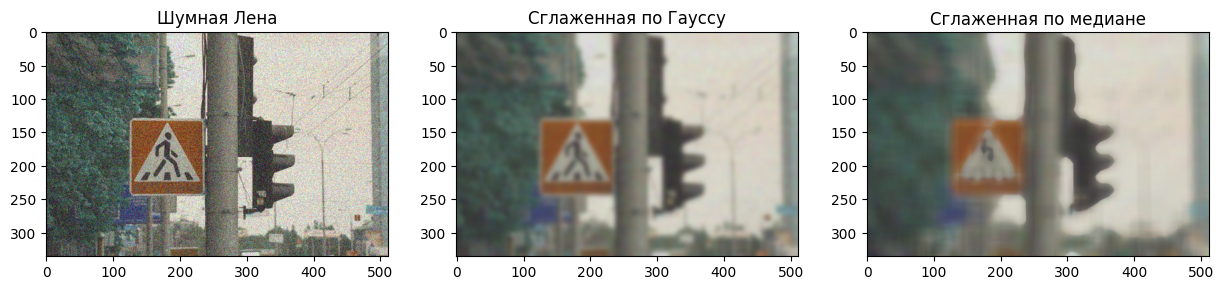

In [34]:
gblurred_img = cv2.GaussianBlur(noisy_img, (21, 21), 0)
mblurred_img = cv2.medianBlur(noisy_img, 21)
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.title('Шумная Лена')
plt.imshow(noisy_img)
plt.subplot(132)
plt.title('Сглаженная по Гауссу')
plt.imshow(gblurred_img)
plt.subplot(133)
plt.title('Сглаженная по медиане')
plt.imshow(mblurred_img)
plt.show()

# Задание 1
Нужно локализовать на изображении дорожный знак пешеходный переход с помощью цветового порога. Результатом у вас должна получиться маска изображения, на которой хорошо выделен дорожный знак. (Рекомендую перевести изображение в HSV и погуглить функцию inRange). Финальную маску изображения попрошу назвать result_image.

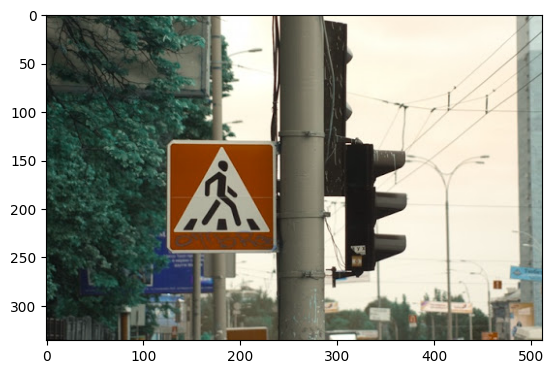

In [35]:
pesh = cv2.imread('peshehod.jpeg')
plt.imshow(pesh) #перепутаны местами каналы, не забудьте))

In [37]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresholded_img = cv2.threshold(
    gray_img,
    180,
    255,
    cv2.THRESH_BINARY
)

result = int(np.sum(thresholded_img) / 255)

print(result)

57838


# Задание 2
Сделайте threshold Лены по порогу выше 180.

In [38]:
### PUT YOUR CODE HERE

#Введите число, полученное в результате выполнения кода ниже в строку для ответов
print(np.sum(thresholded_img)/255)

57838.0


In [39]:
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower = np.array([0, 100, 100])
upper = np.array([10, 255, 255])

result_image = cv2.inRange(hsv_img, lower, upper)

answer = np.sum(result_image[120:250, 120:250]) / np.sum(result_image)

print(answer)

0.02973977695167286
